In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap
import pandas as pd

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


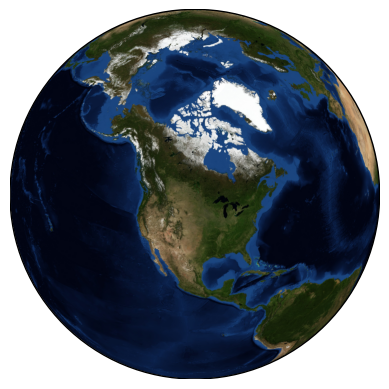

In [2]:
Basemap(projection='ortho', lat_0=50, lon_0=-100, resolution=None).bluemarble(scale=0.5)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


Text(6579178.63877639, 4237049.910151465, 'Mercer University')

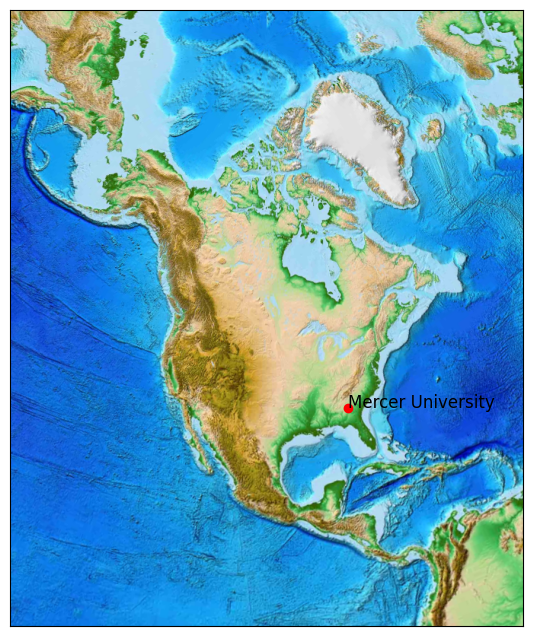

In [3]:
fig = plt.figure(figsize=(8, 8))
m = Basemap(projection='lcc', lat_0=50, lon_0=-100, resolution=None, width=1E7, height=1.2E7)
m.etopo(scale=0.5)
x, y = m(-83.650479, 32.829786)
plt.plot(x, y, 'ro')
plt.text(x, y, 'Mercer University', fontsize=12)

# Map Projections

In [4]:
from itertools import chain
# cell code from source repo
def draw_map(m, scale=0.2):
    # draw a shaded-relief image
    m.shadedrelief(scale=scale)
    
    # lats and longs are returned as a dictionary
    lats = m.drawparallels(np.linspace(-90, 90, 13))
    lons = m.drawmeridians(np.linspace(-180, 180, 13))

    # keys contain the plt.Line2D instances
    lat_lines = chain(*(tup[1][0] for tup in lats.items()))
    lon_lines = chain(*(tup[1][0] for tup in lons.items()))
    all_lines = chain(lat_lines, lon_lines)
    
    # cycle through these lines and set the desired style
    for line in all_lines:
        line.set(linestyle='-', alpha=0.3, color='w')

## cylindrical projection

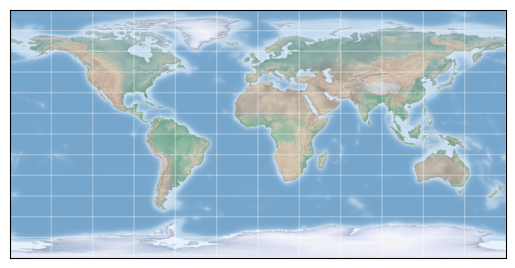

In [5]:
m = Basemap(projection='cyl')
draw_map(m)

## pseudo-cylindrical projection

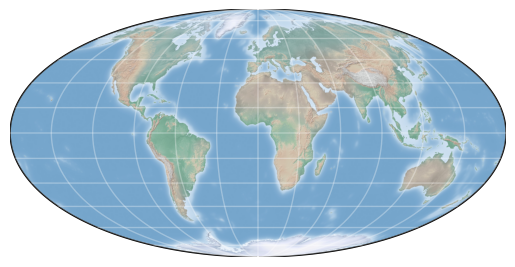

In [6]:
m = Basemap(projection='moll', lon_0=0)
draw_map(m)

## perspective projection

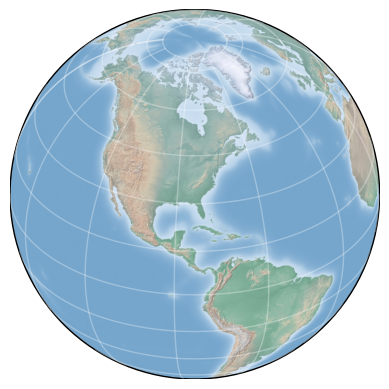

In [7]:
m = Basemap(projection='ortho', resolution=None,
            lon_0=-83.6, lat_0=33)
draw_map(m)

# conic projections

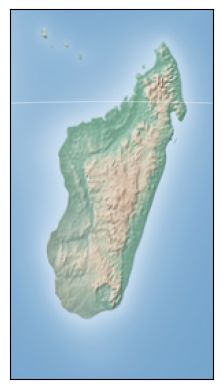

In [8]:
m = Basemap(projection='lcc', lon_0=46.7, lat_0=-19.5, lat_1=-20.0, width=1.1E6, height=2.0E6, resolution='h')
draw_map(m, scale=0.5)

# Drawing a map background

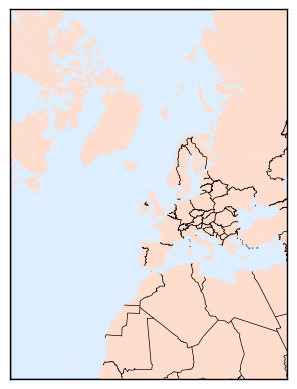

In [9]:
m = Basemap(projection='gnom', lat_0=57.3, lon_0=-6.2,
        width=9000000, height=12000000, resolution='h')
m.fillcontinents(color="#FFDDCC", lake_color='#DDEEFF')
m.drawmapboundary(fill_color="#DDEEFF")
m.drawcountries()

# plotting data on maps

In [10]:
cities = pd.DataFrame({
    'city': ['Antananarivo', 'Toamasina', 'Mahajanga', 'Toliara', 'Fianarantsoa'],
    'lat': [-18.8792, -18.1492, -15.7167, -23.3500, -21.4527],
    'lon': [47.5079, 49.4023, 46.3167, 43.6667, 47.0857],
    'population': [1391433, 325857, 246354, 168756, 200482]
})
cities

,city,lat,lon,population
0,Antananarivo,-18.8792,47.5079,1391433
1,Toamasina,-18.1492,49.4023,325857
2,Mahajanga,-15.7167,46.3167,246354
3,Toliara,-23.3500,43.6667,168756
4,Fianarantsoa,-21.4527,47.0857,200482


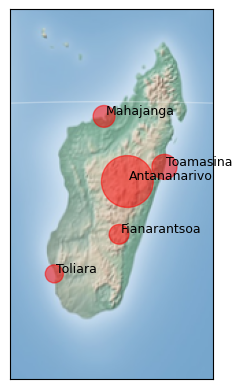

In [12]:
m = Basemap(projection='lcc', lon_0=46.7, lat_0=-19.5, lat_1=-20.0, width=1.1E6, height=2.0E6, resolution='h')
draw_map(m, scale=0.5)
x, y = m(cities.lon.values, cities.lat.values)
m.scatter(x, y, s=cities.population.values/1000, color='red', alpha=0.5)

for city, xi, yi in zip(cities.city.values, x, y):
    plt.text(xi + 10000, yi + 10000, city, fontsize=9, color='black')